In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [2]:
df=pd.read_csv("titanic_dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


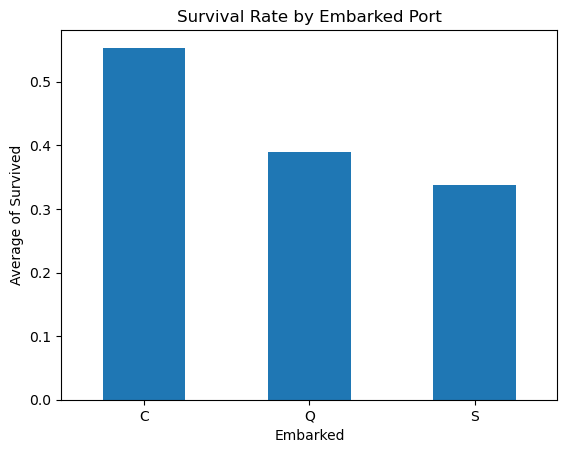

Highest survival rate: C
Rate: 55.36 %


In [3]:
survival_rate = df.groupby("Embarked")["Survived"].mean()

survival_rate.plot(kind="bar")

plt.title("Survival Rate by Embarked Port")
plt.xlabel("Embarked")
plt.ylabel("Average of Survived")
plt.xticks(rotation=0)
plt.show()

print("Highest survival rate:", survival_rate.idxmax())
print("Rate:", round(survival_rate.max() * 100, 2), "%")

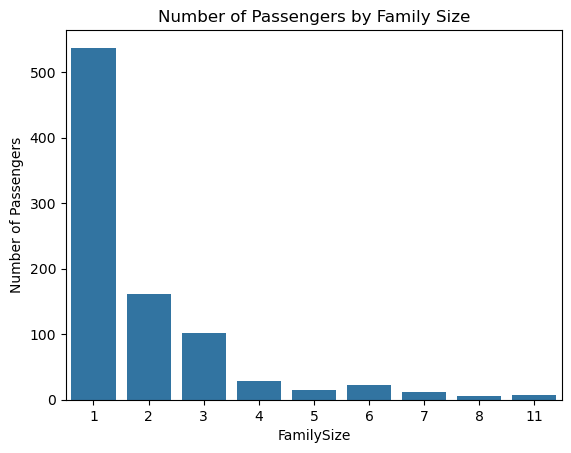

Most common family size: 1
Number of passengers: 537


In [4]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Count Plot
sns.countplot(data=df, x="FamilySize")

plt.title("Number of Passengers by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Number of Passengers")
plt.show()

# Most common family size
most_common = df["FamilySize"].mode()[0]
count = df["FamilySize"].value_counts().max()

print("Most common family size:", most_common)
print("Number of passengers:", count)

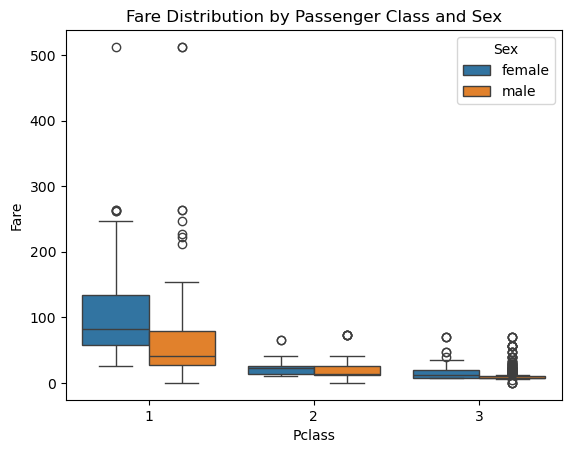

In [5]:
sns.boxplot(data=df, x="Pclass", y="Fare", hue="Sex")

plt.title("Fare Distribution by Passenger Class and Sex")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

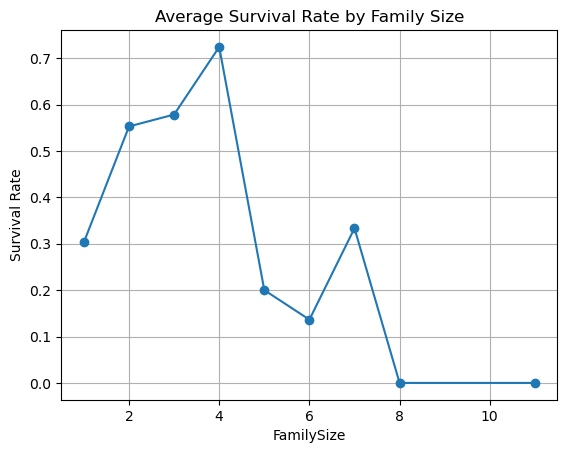

Family size with highest survival rate: 4
Highest survival rate: 72.41 %


In [6]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

survival_rate = df.groupby("FamilySize")["Survived"].mean()

plt.plot(survival_rate.index, survival_rate.values,
         marker="o")

plt.title("Average Survival Rate by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Survival Rate")
plt.grid(True)
plt.show()

highest_family = survival_rate.idxmax()
highest_rate = survival_rate.max()

print("Family size with highest survival rate:", highest_family)
print("Highest survival rate:", round(highest_rate * 100, 2), "%")